<a href="https://colab.research.google.com/github/alinasagaydak/diplom/blob/main/pytorch_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

In [2]:
# Установка seed для воспроизводимости
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определение устройства (GPU если доступен)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cpu


In [3]:
class TrackClassifier(nn.Module):
    """
    Классификатор для треков из дрейфовой камеры.
    Определяет: пучковая пара (0) или конверсионная пара (1)
    """
    def __init__(self, input_dim=11, hidden_dims=[16, 8], dropout_rate=0.3):
        super(TrackClassifier, self).__init__()

        layers = []
        prev_dim = input_dim

        # Создание скрытых слоев
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim

        # Выходной слой
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [4]:
class TrackDataProcessor:
    """Класс для обработки данных треков"""

    def __init__(self, scaler=None):
        self.scaler = scaler if scaler else StandardScaler()
        self.feature_names = [f'param_{i+1}' for i in range(7)]

    def preprocess(self, X, y=None, fit_scaler=False):
        """
        Предобработка данных: нормализация и преобразование в тензоры

        Parameters:
        -----------
        X : numpy.ndarray, shape (n_samples, 11)
            Входные параметры треков
        y : numpy.ndarray, shape (n_samples,), optional
            Метки классов
        fit_scaler : bool
            Нужно ли обучать scaler на этих данных
        """
        # Нормализация
        if fit_scaler:
            X_normalized = self.scaler.fit_transform(X)
        else:
            X_normalized = self.scaler.transform(X)

        # Преобразование в тензоры
        X_tensor = torch.FloatTensor(X_normalized).to(device)

        if y is not None:
            y_tensor = torch.FloatTensor(y).reshape(-1, 1).to(device)
            return X_tensor, y_tensor

        return X_tensor

    def inverse_transform(self, X):
        """Обратное преобразование нормализованных данных"""
        if isinstance(X, torch.Tensor):
            X = X.cpu().numpy()
        return self.scaler.inverse_transform(X)

In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100, patience=20):
    """
    Обучение модели с ранней остановкой

    Returns:
    --------
    dict: История обучения (потери и метрики)
    """
    model.train()
    train_losses = []
    val_losses = []
    val_accuracies = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        # Обучение
        model.train()
        epoch_train_loss = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Валидация
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                # Предсказания для метрик
                preds = torch.sigmoid(outputs)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Метрики
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        predictions = (all_preds > 0.5).astype(int)
        accuracy = accuracy_score(all_labels, predictions)
        val_accuracies.append(accuracy)

        # Обновление learning rate
        if scheduler:
            scheduler.step(avg_val_loss)

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Сохраняем лучшую модель
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping на эпохе {epoch+1}')
                break

        if (epoch + 1) % 10 == 0:
            print(f'Эпоха [{epoch+1}/{epochs}] - '
                  f'Train Loss: {avg_train_loss:.4f}, '
                  f'Val Loss: {avg_val_loss:.4f}, '
                  f'Val Acc: {accuracy:.4f}')

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }

In [6]:
def evaluate_model(model, test_loader, threshold=0.5):
    """
    Оценка модели на тестовых данных
    """
    model.eval()
    all_preds_proba = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            preds = torch.sigmoid(outputs)
            all_preds_proba.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    all_preds_proba = np.array(all_preds_proba)
    all_labels = np.array(all_labels)
    all_preds = (all_preds_proba > threshold).astype(int)

    # Вычисление метрик
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall': recall_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds),
        'roc_auc': roc_auc_score(all_labels, all_preds_proba),
        'confusion_matrix': confusion_matrix(all_labels, all_preds)
    }

    return metrics, all_preds_proba, all_labels

In [7]:
def plot_results(history, metrics, all_preds_proba, all_labels):
    """Визуализация результатов обучения и оценки"""

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Потери
    axes[0, 0].plot(history['train_losses'], label='Train Loss', alpha=0.7)
    axes[0, 0].plot(history['val_losses'], label='Validation Loss', alpha=0.7)
    axes[0, 0].set_xlabel('Эпоха')
    axes[0, 0].set_ylabel('Потери')
    axes[0, 0].set_title('Кривые обучения')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Точность на валидации
    axes[0, 1].plot(history['val_accuracies'], label='Validation Accuracy', color='green')
    axes[0, 1].set_xlabel('Эпоха')
    axes[0, 1].set_ylabel('Точность')
    axes[0, 1].set_title('Точность на валидации')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Confusion Matrix
    cm = metrics['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2])
    axes[0, 2].set_xlabel('Предсказанный класс')
    axes[0, 2].set_ylabel('Истинный класс')
    axes[0, 2].set_title('Матрица ошибок')
    axes[0, 2].set_xticklabels(['Пучковая', 'Конверсионная'])
    axes[0, 2].set_yticklabels(['Пучковая', 'Конверсионная'])

    # 4. Метрики в виде bar plot
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    metrics_values = [metrics['accuracy'], metrics['precision'],
                     metrics['recall'], metrics['f1'], metrics['roc_auc']]
    axes[1, 0].bar(metrics_names, metrics_values, color='skyblue', alpha=0.7)
    axes[1, 0].set_ylim([0, 1])
    axes[1, 0].set_ylabel('Значение')
    axes[1, 0].set_title('Метрики качества')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 5. Распределение предсказаний
    axes[1, 1].hist(all_preds_proba[all_labels == 0], bins=30, alpha=0.5,
                    label='Пучковая (класс 0)', color='blue')
    axes[1, 1].hist(all_preds_proba[all_labels == 1], bins=30, alpha=0.5,
                    label='Конверсионная (класс 1)', color='red')
    axes[1, 1].set_xlabel('Вероятность принадлежности к классу 1')
    axes[1, 1].set_ylabel('Количество')
    axes[1, 1].set_title('Распределение вероятностей')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 6. ROC Curve
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(all_labels, all_preds_proba)
    axes[1, 2].plot(fpr, tpr, label=f'ROC Curve (AUC = {metrics["roc_auc"]:.3f})')
    axes[1, 2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    axes[1, 2].set_xlabel('False Positive Rate')
    axes[1, 2].set_ylabel('True Positive Rate')
    axes[1, 2].set_title('ROC Curve')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [8]:
def main():
    """
    Основная функция для обучения и оценки модели
    """
    print("=" * 60)
    print("Классификация треков из дрейфовой камеры")
    print("Определение: пучковая пара (0) vs конверсионная пара (1)")
    print("=" * 60)

    # Генерация синтетических данных (замените на ваши реальные данные)
    # Ваши данные должны иметь форму: X - (n_samples, 7), y - (n_samples,)
    np.random.seed(42)


    # Создание синтетических данных с физически значимыми параметрами
    # В реальном коде загрузите ваши данные здесь
    #X = np.random.randn(n_samples, 7) * 0.5 + np.array([0.1, -0.2, 0.3, -0.1, 0.2, 0.1, -0.3])
    # Добавляем различие между классами
    #y = (X[:, 0] * 0.5 + X[:, 1] * 0.3 + X[:, 2] * 0.2 + np.random.randn(n_samples) * 0.3 > 0).astype(int)

    X = []
    y = []
    events_lst = []

    with open("vars.txt") as ifile:
      for line in ifile:
        line = line.strip("\n")
        tmp_event_lst = line.rsplit(" ")
        events_lst.append([float(var) for var in tmp_event_lst])
    random.shuffle(events_lst)

    for i in range(len(events_lst)):
      X.append([float(var) for var in events_lst[i][:11]])
      y.append(int(events_lst[i][-1]))

    X = np.array(X)
    y = np.array(y)

    n_samples = len(events_lst)

    # Разделение данных
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    print(f"\nРазмеры выборок:")
    print(f"Обучающая: {X_train.shape[0]} образцов")
    print(f"Валидационная: {X_val.shape[0]} образцов")
    print(f"Тестовая: {X_test.shape[0]} образцов")
    print(f"Баланс классов в обучающей выборке: {np.sum(y_train)/len(y_train):.3f}")

    # Предобработка данных
    processor = TrackDataProcessor()
    X_train_tensor, y_train_tensor = processor.preprocess(X_train, y_train, fit_scaler=True)
    X_val_tensor, y_val_tensor = processor.preprocess(X_val, y_val, fit_scaler=False)
    X_test_tensor, y_test_tensor = processor.preprocess(X_test, y_test, fit_scaler=False)

    # Создание DataLoader'ов
    batch_size = 64
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

    # Взвешенный sampler для несбалансированных данных (если необходимо)
    class_counts = np.bincount(y_train)
    class_weights = 1. / class_counts
    sample_weights = class_weights[y_train]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)

    # Создание модели
    model = TrackClassifier(input_dim=11, hidden_dims=[32, 16, 8], dropout_rate=0.3).to(device)
    print(f"\nАрхитектура модели:\n{model}")

    # Подсчет параметров
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nВсего параметров: {total_params:,}")
    print(f"Обучаемых параметров: {trainable_params:,}")

    # Функция потерь и оптимизатор
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # Обучение
    print("\nНачало обучения...")
    history = train_model(
        model, train_loader, val_loader,
        criterion, optimizer, scheduler,
        epochs=100, patience=20
    )

    # Загрузка лучшей модели
    model.load_state_dict(torch.load('best_model.pth'))

    # Оценка
    print("\nОценка модели на тестовых данных...")
    metrics, preds_proba, true_labels = evaluate_model(model, test_loader)

    # Вывод результатов
    print("\n" + "=" * 60)
    print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:")
    print("=" * 60)
    print(f"Точность (Accuracy):  {metrics['accuracy']:.4f}")
    print(f"Точность (Precision): {metrics['precision']:.4f}")
    print(f"Полнота (Recall):     {metrics['recall']:.4f}")
    print(f"F1-мера:              {metrics['f1']:.4f}")
    print(f"ROC-AUC:              {metrics['roc_auc']:.4f}")
    print("\nМатрица ошибок:")
    print(metrics['confusion_matrix'])

    # Визуализация
    plot_results(history, metrics, preds_proba, true_labels)

    # Сохранение модели для использования
    torch.save({
        'model_state_dict': model.state_dict(),
        'scaler': processor.scaler,
        'model_architecture': model.network,
        'input_dim': 11
    }, 'track_classifier_complete.pth')
    print("\nМодель сохранена в 'track_classifier_complete.pth'")

    return model, processor, metrics

Классификация треков из дрейфовой камеры
Определение: пучковая пара (0) vs конверсионная пара (1)

Размеры выборок:
Обучающая: 4754 образцов
Валидационная: 1019 образцов
Тестовая: 1019 образцов
Баланс классов в обучающей выборке: 0.501

Архитектура модели:
TrackClassifier(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=8, bias=True)
    (9): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=8, out_features=1, bias=True)
  )
)

Всего параметров: 1,169

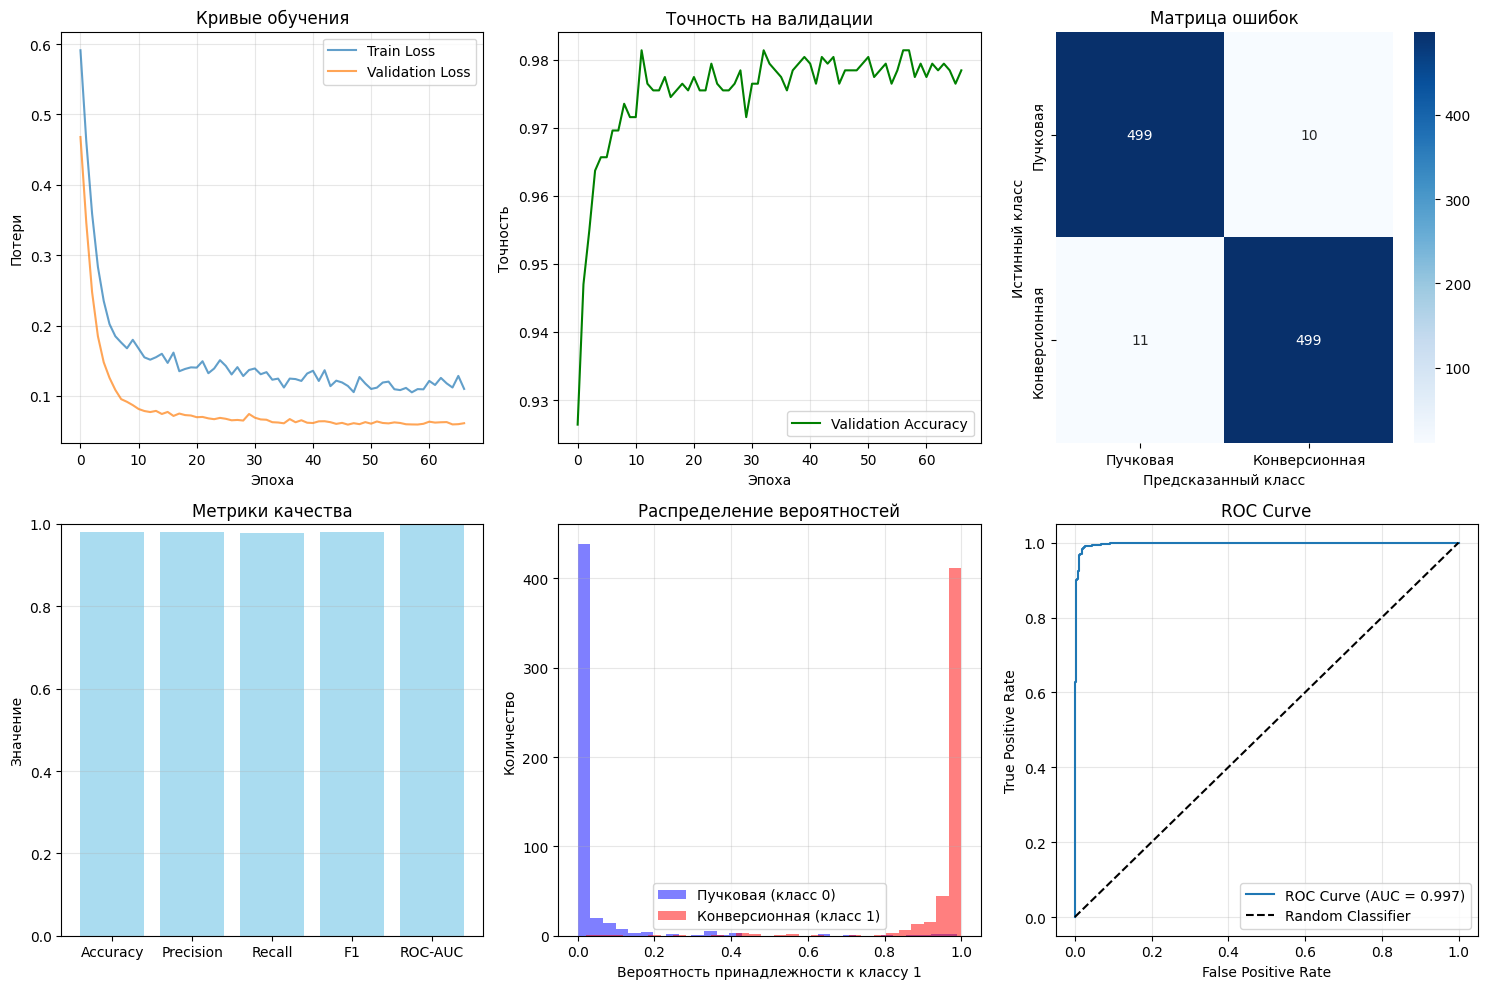


Модель сохранена в 'track_classifier_complete.pth'


In [9]:
if __name__ == "__main__":
    model, processor, metrics = main()

    # # Пример предсказания для новых данных
    # print("\n" + "=" * 60)
    # print("ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВЫХ ТРЕКОВ:")
    # print("=" * 60)

    # # Создание тестового образца (замените на реальные данные)
    # new_track = np.random.randn(1, 7) * 0.5 + np.array([0.1, -0.2, 0.3, -0.1, 0.2, 0.1, -0.3])

    # # Предобработка
    # new_track_tensor = processor.preprocess(new_track, fit_scaler=False)

    # # Предсказание
    # model.eval()
    # with torch.no_grad():
    #     output = model(new_track_tensor)
    #     probability = torch.sigmoid(output).cpu().numpy()[0, 0]
    #     prediction = "Конверсионная пара" if probability > 0.5 else "Пучковая пара"
    #     confidence = probability if probability > 0.5 else 1 - probability

    # print(f"Входные параметры трека: {new_track[0]}")
    # print(f"Предсказание: {prediction}")
    # print(f"Уверенность: {confidence:.2%}")